# Представлена задача кредитного скоринга

# Зарузка данных и импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_credit = pd.read_csv(r"german_credit_data.csv")
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   laufkont  1000 non-null   int64
 1   laufzeit  1000 non-null   int64
 2   moral     1000 non-null   int64
 3   verw      1000 non-null   int64
 4   hoehe     1000 non-null   int64
 5   sparkont  1000 non-null   int64
 6   beszeit   1000 non-null   int64
 7   rate      1000 non-null   int64
 8   famges    1000 non-null   int64
 9   buerge    1000 non-null   int64
 10  wohnzeit  1000 non-null   int64
 11  verm      1000 non-null   int64
 12  alter     1000 non-null   int64
 13  weitkred  1000 non-null   int64
 14  wohn      1000 non-null   int64
 15  bishkred  1000 non-null   int64
 16  beruf     1000 non-null   int64
 17  pers      1000 non-null   int64
 18  telef     1000 non-null   int64
 19  gastarb   1000 non-null   int64
 20  kredit    1000 non-null   int64
dtypes: int64(21)
memory usage: 164.2 KB


In [2]:
df_credit.head()

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [3]:
df_credit.describe()

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,...,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.577000,20.903000,2.54500,2.828000,3271.24800,2.105000,3.384000,2.973000,2.68200,1.145000,...,2.358000,35.54200,2.675000,1.928000,1.407000,2.904000,1.845000,1.404000,1.963000,0.700000
std,1.257638,12.058814,1.08312,2.744439,2822.75176,1.580023,1.208306,1.118715,0.70808,0.477706,...,1.050209,11.35267,0.705601,0.530186,0.577654,0.653614,0.362086,0.490943,0.188856,0.458487
min,1.000000,4.000000,0.00000,0.000000,250.00000,1.000000,1.000000,1.000000,1.00000,1.000000,...,1.000000,19.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.000000,12.000000,2.00000,1.000000,1365.50000,1.000000,3.000000,2.000000,2.00000,1.000000,...,1.000000,27.00000,3.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,0.000000
50%,2.000000,18.000000,2.00000,2.000000,2319.50000,1.000000,3.000000,3.000000,3.00000,1.000000,...,2.000000,33.00000,3.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,1.000000
75%,4.000000,24.000000,4.00000,3.000000,3972.25000,3.000000,5.000000,4.000000,3.00000,1.000000,...,3.000000,42.00000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,1.000000
max,4.000000,72.000000,4.00000,10.000000,18424.00000,5.000000,5.000000,4.000000,4.00000,3.000000,...,4.000000,75.00000,3.000000,3.000000,4.000000,4.000000,2.000000,2.000000,2.000000,1.000000


# В данных нет пропусков
### но мне не нравится, что 1 - хорошо, а 0 - дефолт, обычно в задачах кридитного скоринга 1 - дефолт, а 0 - не дефолт. Поэтому сконвертируем подругому заранее!


In [4]:
df_credit['kredit'] = 1 - df_credit['kredit']


In [5]:
X = df_credit.drop('kredit', axis=1)
y = df_credit['kredit']


## Теперь в задаче кридитного скоринга считаем 1 - за дефолт

## Построим матрицу корреляции для понимания наиболее/наименее значимых признаков.

<Axes: >

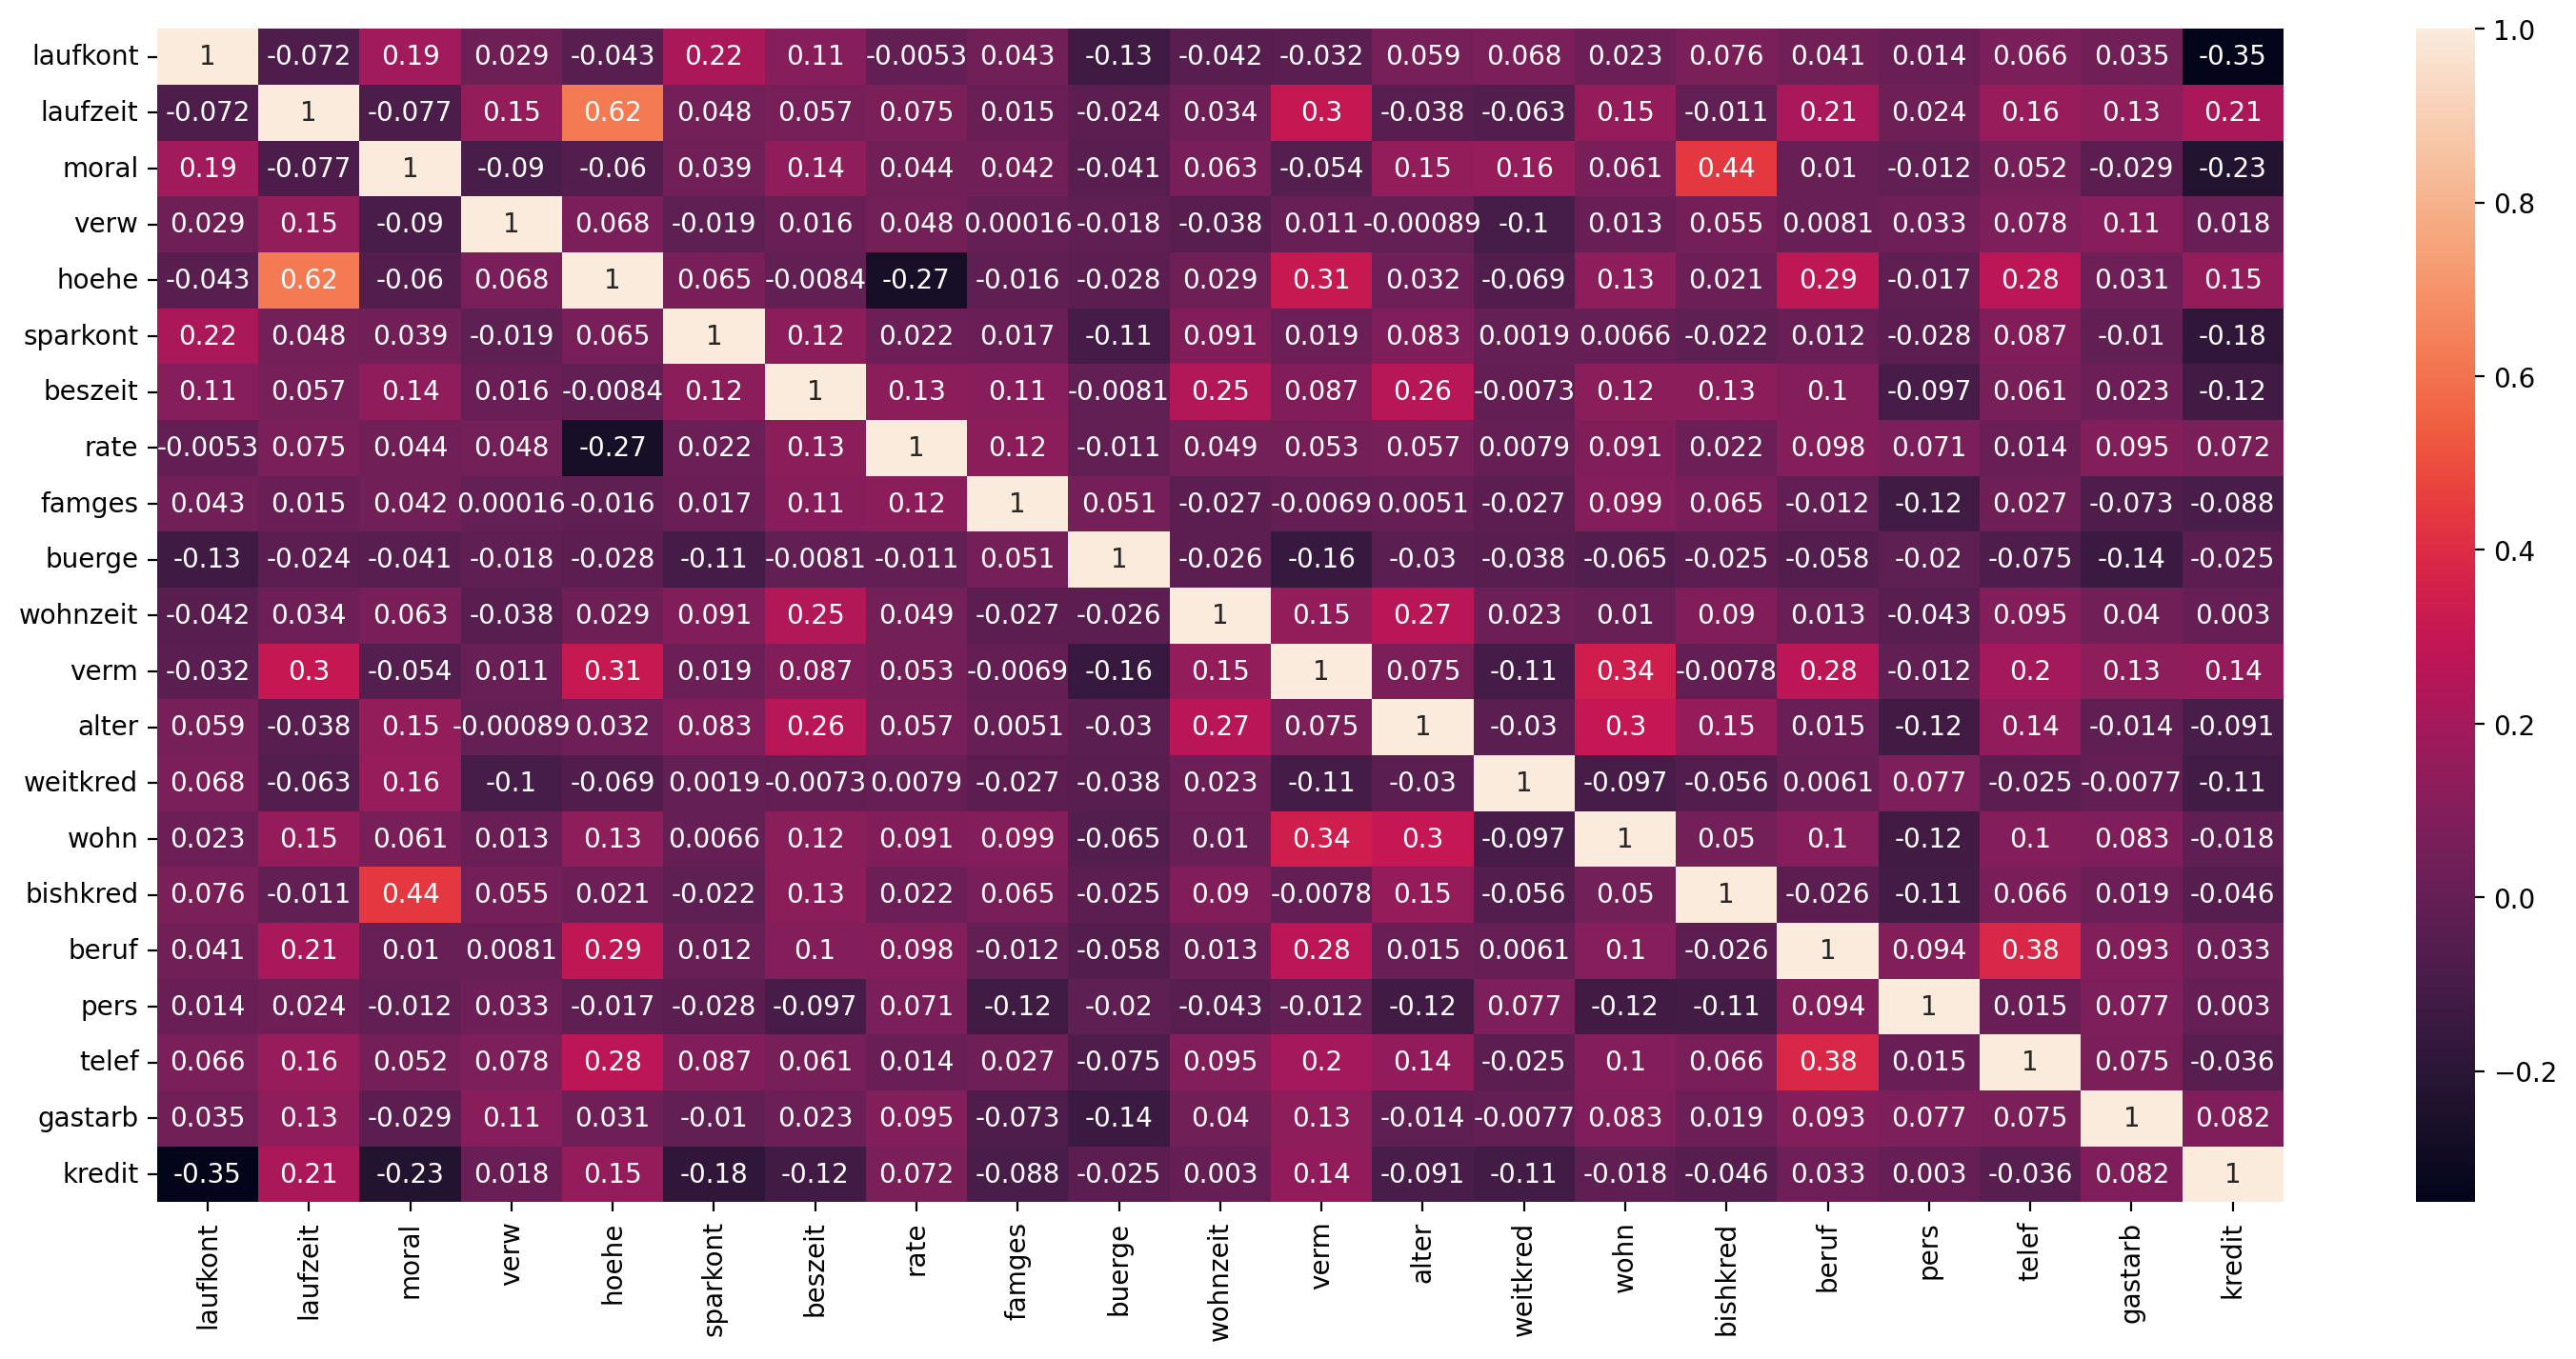

In [6]:
fig, ax = plt.subplots(figsize=(18,8), dpi=200)
sns.heatmap(df_credit.corr(numeric_only=True), annot=True, ax=ax)

In [7]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report, PrecisionRecallDisplay, RocCurveDisplay

## Перед обучением модели, мы должны понять, с какими данными мы имеем дело, со сбалансированными или нет

In [8]:
y.value_counts()

kredit
0    700
1    300
Name: count, dtype: int64

### Данные сбалансированы

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=101)

scaler = StandardScaler()
X_scaler_train = scaler.fit_transform(X_train)
X_scaler_test  = scaler.transform(X_test)

model_first = LogisticRegression()

scores = cross_val_score(estimator=model_first, X=X_scaler_train, y=y_train, scoring='roc_auc_ovr', cv=5)

scores.mean()

np.float64(0.7690476190476192)

In [10]:
model_first.fit(X_scaler_train, y_train)
y_predict = model_first.predict(X_scaler_test)

acc = accuracy_score(y_test, y_predict)
acc

0.7566666666666667

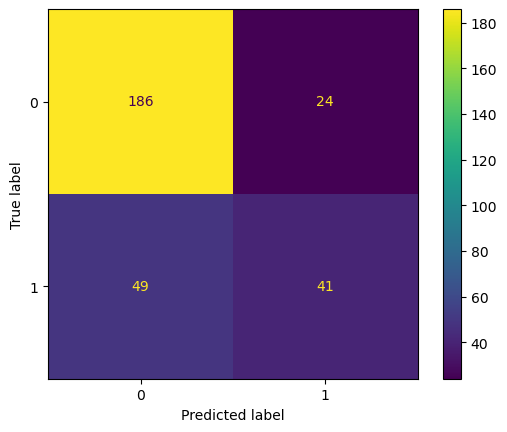

In [11]:
ConfusionMatrixDisplay.from_estimator(model_first, X_scaler_test, y_test)

In [12]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.79      0.89      0.84       210
           1       0.63      0.46      0.53        90

    accuracy                           0.76       300
   macro avg       0.71      0.67      0.68       300
weighted avg       0.74      0.76      0.74       300



## Итог первой модели

По метрикам оценки модели мы можем понять, что модель действует по принципу большего риска, пропуская дефолтных заемщиков, но и еще отклоняет большое количество платежно способных клиентов, что говорит о неготовности модели для вывода в продакшн, нам не нужна такая модель.

## Cпособы улучшения модели

###  1. Изменим параметр class_weight='balanced'
Потому что Logistic Regression оптимизирует Accuracy (или логарифмическую функцию потерь), усредненную по всем объектам. В нашей выборке 210 хороших и 90 плохих. Чтобы получить низкий overall loss, модели выгоднее "забить" на класс 0 (не дефолт), потому что ошибка на одном дефолте стоит в лоссе столько же, сколько ошибка на одном хорошем. Но хороших в 2.3 раза больше! Поэтому градиентный спуск смещает веса так, чтобы угодить большинству, поэтому модель будет работать некорректно.

### 2. Сдвиг порога
На данный момент выбор модели к какому классу относить лежит на значении порога 50 %, если попробовать уменьшить этот порог, то мы можем получит совсем другие результаты

### 3. Создадим новый признак, который будет сильнее коррелировать с целевой переменной
к примеру можно создать признак - **сумма_кредита/ доход**, который покажет хороший результат и хорошую предсказатльную базу

## Я попробую использовать первые два варианта, если результат модели устроит. Можно будет не притрагиваться к третьему варианту

In [13]:
model_two = LogisticRegression(class_weight='balanced')
model_two.fit(X_scaler_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [14]:
scores = cross_val_score(estimator=model_two, X=X_scaler_train, y=y_train, scoring='roc_auc_ovr', cv=5)

scores.mean()

np.float64(0.7687074829931974)

In [15]:
y_proba = model_two.predict_proba(X_scaler_test)

# Получаем вероятность для тестовой выборки
# predict_proba возвращает массив из двух колонок: [ [вероятность_класса_0, вероятность_класса_1] ]

In [16]:
y_proba[:5]

array([[0.70662757, 0.29337243],
       [0.58340673, 0.41659327],
       [0.92137754, 0.07862246],
       [0.36923118, 0.63076882],
       [0.65648193, 0.34351807]])

In [17]:
# Берем ВТОРУЮ колонку [:, 1] — это вероятность класса "1" (в наших инвертированных метках — дефолт)
# Если вероятность дефолта > 0.3, назначаем класс 1, иначе класс 0
y_pred_custom = np.where(y_proba[:, 1] > 0.3, 1, 0)
y_pred_custom[:5]

array([0, 1, 0, 1, 1])

In [18]:
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.94      0.43      0.59       210
           1       0.41      0.93      0.57        90

    accuracy                           0.58       300
   macro avg       0.68      0.68      0.58       300
weighted avg       0.78      0.58      0.59       300



## Вывод от этой модели
Увеличив recall на 1 классе мы имеем это: из **100** не платежноспособных клиентов, мы смогли **93** смогли обнаружить.
Но метрика precision на 1 классе показала нам, что из **100** человек, отказанных моделью, **59** человек были способными своевременно платить банку.
То есть для бизнеса мы получили два вывода. Мы понизили количество тех, кто не оплатит, но и понизили прибыль бизнеса, отказывая больше половине клиентам нашего банка.\
Результат модели стал лучше.\
\
**Следущая цель:** повысить precision на классе 1, попробуем повысить порог с 0.3 до 0.4

In [19]:
model_three = LogisticRegression(class_weight='balanced', random_state=101)
model_three.fit(X_scaler_train, y_train)
y_proba_three = model_three.predict_proba(X_scaler_test)
y_pred_three = np.where(y_proba_three[:, 1] > 0.4, 1, 0)

print(classification_report(y_test, y_pred_three))

              precision    recall  f1-score   support

           0       0.90      0.63      0.75       210
           1       0.50      0.84      0.63        90

    accuracy                           0.70       300
   macro avg       0.70      0.74      0.69       300
weighted avg       0.78      0.70      0.71       300



## Вывод

на данном этапе можно остановится, но мы повысим порог до 0.45, а после создадим новую модель, в которой будем взаимодействовать с новым признаком - сумма_кредита делённая на доход, будем искать наиболее выгодную модель для бизнеса

In [20]:
model_45 = LogisticRegression(class_weight='balanced', random_state=101)
model_45.fit(X_scaler_train, y_train)
y_proba_45 = model_45.predict_proba(X_scaler_test)
y_pred_45 = np.where(y_proba_45[:, 1] > 0.45, 1, 0)

print(classification_report(y_test, y_pred_45))

              precision    recall  f1-score   support

           0       0.88      0.70      0.78       210
           1       0.53      0.79      0.63        90

    accuracy                           0.72       300
   macro avg       0.71      0.74      0.70       300
weighted avg       0.78      0.72      0.73       300



In [21]:
df_copy = df_credit.copy()
df_copy.columns

Index(['laufkont', 'laufzeit', 'moral', 'verw', 'hoehe', 'sparkont', 'beszeit',
       'rate', 'famges', 'buerge', 'wohnzeit', 'verm', 'alter', 'weitkred',
       'wohn', 'bishkred', 'beruf', 'pers', 'telef', 'gastarb', 'kredit'],
      dtype='object')

В датасете нет прямой колонки с доходом заёмщика, но есть две важные колонки, которые помогут создать нужный признак.
**rate** - Это процент от дохода, который уходит на ежемесячный платёж по кредиту.\
**hoehe** -  Это размер запрашиваемого кредита в немецких марках. Это количественный признак, который и есть ваша сумма кредита.

In [22]:
df_copy['dolg_nagruzka'] = df_copy['hoehe'] * df_copy['rate'] / 100

rate — это процент от дохода, который уходит на платёж. Умножив сумму кредита на этот процент, вы получите примерную ежемесячную нагрузку в абсолютных цифрах. Чем выше значение, тем рискованнее клиент.

In [23]:
df_copy.shape

(1000, 22)

In [24]:

X_new = df_copy.drop('kredit', axis=1)
y_new = df_copy['kredit']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.3, random_state=101)
scaler_new = StandardScaler()
X_scaler_train_new = scaler_new.fit_transform(X_train_new)
X_scaler_test_new = scaler_new.transform(X_test_new)

model_new = LogisticRegression(class_weight='balanced', random_state=101)
model_new.fit(X_scaler_train_new, y_train_new)

y_proba_new = model_new.predict_proba(X_scaler_test_new)

for th in [0.35, 0.4, 0.45]:
    y_pred_new = np.where(y_proba_new[:, 1] > th, 1, 0)
    print(f"--- Порог: {th} ---")
    print(classification_report(y_test_new, y_pred_new))

--- Порог: 0.35 ---
              precision    recall  f1-score   support

           0       0.91      0.55      0.68       210
           1       0.45      0.87      0.59        90

    accuracy                           0.64       300
   macro avg       0.68      0.71      0.64       300
weighted avg       0.77      0.64      0.66       300

--- Порог: 0.4 ---
              precision    recall  f1-score   support

           0       0.90      0.63      0.75       210
           1       0.50      0.84      0.63        90

    accuracy                           0.70       300
   macro avg       0.70      0.74      0.69       300
weighted avg       0.78      0.70      0.71       300

--- Порог: 0.45 ---
              precision    recall  f1-score   support

           0       0.88      0.70      0.78       210
           1       0.53      0.79      0.63        90

    accuracy                           0.72       300
   macro avg       0.71      0.74      0.70       300
weighted avg   

In [25]:
df_copy = df_credit.copy()

df_copy['implied_income'] = df_copy['hoehe'] / (df_copy['rate'] / 100)

X_new = df_copy.drop('kredit', axis=1)
y_new = df_copy['kredit']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.3, random_state=101)

scaler_new = StandardScaler()
X_scaler_train_new = scaler_new.fit_transform(X_train_new)
X_scaler_test_new = scaler_new.transform(X_test_new)

model_new = LogisticRegression(class_weight='balanced', random_state=101)
model_new.fit(X_scaler_train_new, y_train_new)
y_proba_new = model_new.predict_proba(X_scaler_test_new)

for th in [0.4, 0.45]:
    y_pred_new = np.where(y_proba_new[:, 1] > th, 1, 0)
    print(f"--- Порог: {th} ---")
    print(classification_report(y_test_new, y_pred_new))

--- Порог: 0.4 ---
              precision    recall  f1-score   support

           0       0.90      0.63      0.75       210
           1       0.50      0.84      0.63        90

    accuracy                           0.70       300
   macro avg       0.70      0.74      0.69       300
weighted avg       0.78      0.70      0.71       300

--- Порог: 0.45 ---
              precision    recall  f1-score   support

           0       0.88      0.70      0.78       210
           1       0.53      0.79      0.63        90

    accuracy                           0.72       300
   macro avg       0.71      0.74      0.70       300
weighted avg       0.78      0.72      0.73       300

